# Building a Transformer LLM — Layer by Layer with Visualizations

This notebook builds a GPT-style transformer from scratch in PyTorch and visualizes every major component using **Matplotlib** and **Plotly**.

**What we build and visualize:**
1. Token Embeddings + Positional Encoding
2. Scaled Dot-Product Attention
3. Multi-Head Attention
4. Feed-Forward Network
5. Residual Connections + Layer Norm
6. Full Transformer Block
7. Stack of N Layers → Language Model Head
8. Forward Pass Activations
9. Attention Pattern Heatmaps
10. Embedding Space (PCA projection)

In [ ]:
# Install required packages if needed
# !pip install torch matplotlib plotly seaborn scikit-learn numpy

In [9]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Style
plt.style.use('dark_background')
ACCENT  = '#7c6aff'
ACCENT2 = '#34d399'
GOLD    = '#fbbf24'
ROSE    = '#f87171'

print('PyTorch:', torch.__version__)
print('Device: ', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.6.0
Device:  cpu


---
## 1. Hyperparameters
These are the dimensions that flow through the entire model. We use a small config for clarity.

In [10]:
# ── Model hyperparameters ──────────────────────────────────────
VOCAB_SIZE  = 50          # small vocabulary for illustration
D_MODEL     = 32          # embedding / residual stream dimension
N_HEADS     = 4           # number of attention heads
D_HEAD      = D_MODEL // N_HEADS   # 8 per head
D_FF        = D_MODEL * 4          # 128 — feed-forward inner dim
N_LAYERS    = 3           # transformer blocks stacked
MAX_SEQ_LEN = 16          # maximum sequence length
DROPOUT     = 0.1

# Sample sequence: 8 tokens, batch size 1
BATCH       = 1
SEQ_LEN     = 8
token_ids   = torch.randint(0, VOCAB_SIZE, (BATCH, SEQ_LEN))

print(f'D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, D_HEAD={D_HEAD}, D_FF={D_FF}')
print(f'Input token IDs: {token_ids[0].tolist()}')

D_MODEL=32, N_HEADS=4, D_HEAD=8, D_FF=128
Input token IDs: [42, 17, 26, 14, 26, 35, 20, 24]


---
## 2. Token Embeddings + Sinusoidal Positional Encoding

Each token ID is looked up in an embedding table (shape: `vocab_size × d_model`).  
A **sinusoidal positional encoding** is added so the model knows token order.

$$PE(pos, 2i)   = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [11]:
class TokenEmbedding(nn.Module):
    """Learnable token embedding lookup table."""
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        # Scale by sqrt(d_model) per original paper
        self.scale = math.sqrt(d_model)

    def forward(self, x):
        return self.embed(x) * self.scale


class SinusoidalPE(nn.Module):
    """Fixed sinusoidal positional encoding (not learned)."""
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build PE table: shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()       # (max_len, 1)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * -(math.log(10000.0) / d_model))          # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)   # even dims
        pe[:, 1::2] = torch.cos(pos * div)   # odd dims
        pe = pe.unsqueeze(0)                  # (1, max_len, d_model)
        self.register_buffer('pe', pe)        # not a parameter, but saved with model

    def forward(self, x):
        # x: (batch, seq, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


# Instantiate
tok_emb = TokenEmbedding(VOCAB_SIZE, D_MODEL)
pos_enc = SinusoidalPE(D_MODEL, MAX_SEQ_LEN, DROPOUT)

# Forward pass through embeddings
x_emb = tok_emb(token_ids)          # (1, 8, 32)
x     = pos_enc(x_emb)              # (1, 8, 32)  — residual stream starts here
print('After embedding + PE:', x.shape)

After embedding + PE: torch.Size([1, 8, 32])


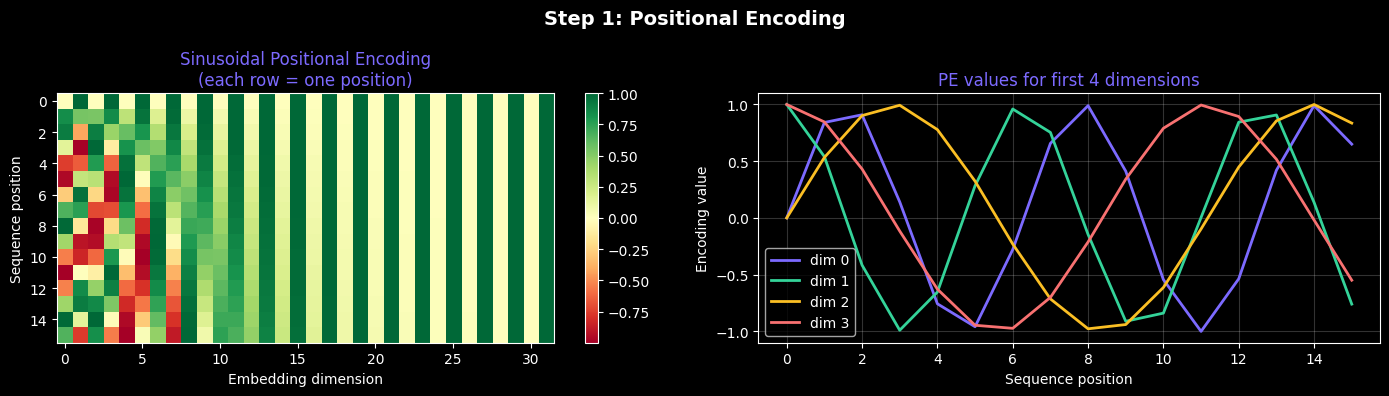


Token embeddings shape: torch.Size([1, 8, 32])
After +PE shape:         torch.Size([1, 8, 32])


In [12]:
# ── Visualize the sinusoidal PE table ───────────────────────────
pe_np = pos_enc.pe[0, :MAX_SEQ_LEN, :].numpy()   # (16, 32)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(pe_np, aspect='auto', cmap='RdYlGn', interpolation='none')
axes[0].set_xlabel('Embedding dimension', color='white')
axes[0].set_ylabel('Sequence position', color='white')
axes[0].set_title('Sinusoidal Positional Encoding\n(each row = one position)', color=ACCENT)
plt.colorbar(im, ax=axes[0])

# First 4 dimensions vs position
for i in range(4):
    axes[1].plot(pe_np[:, i], label=f'dim {i}',
                 color=[ACCENT, ACCENT2, GOLD, ROSE][i], linewidth=2)
axes[1].set_xlabel('Sequence position', color='white')
axes[1].set_ylabel('Encoding value', color='white')
axes[1].set_title('PE values for first 4 dimensions', color=ACCENT)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.suptitle('Step 1: Positional Encoding', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nToken embeddings shape: {x_emb.shape}')
print(f'After +PE shape:         {x.shape}')

---
## 3. Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q** (queries) — what each token is looking for  
- **K** (keys)    — what each token offers  
- **V** (values)  — what gets aggregated  
- The causal mask sets future positions to −∞ before softmax

In [13]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, heads, seq, d_head)
    Returns: (output, attention_weights)
    """
    d_k = Q.size(-1)
    # Compute raw scores: (batch, heads, seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Apply causal mask — prevent attending to future tokens
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Normalize to probability distribution
    attn_weights = F.softmax(scores, dim=-1)

    # Weighted sum of values
    output = torch.matmul(attn_weights, V)
    return output, attn_weights


# Demo with random Q, K, V
Q_demo = torch.randn(BATCH, N_HEADS, SEQ_LEN, D_HEAD)
K_demo = torch.randn(BATCH, N_HEADS, SEQ_LEN, D_HEAD)
V_demo = torch.randn(BATCH, N_HEADS, SEQ_LEN, D_HEAD)

# Causal mask: lower triangular matrix
causal_mask = torch.tril(torch.ones(SEQ_LEN, SEQ_LEN)).unsqueeze(0).unsqueeze(0)

out_demo, attn_demo = scaled_dot_product_attention(Q_demo, K_demo, V_demo, causal_mask)
print('Attention output shape:  ', out_demo.shape)
print('Attention weights shape: ', attn_demo.shape)

Attention output shape:   torch.Size([1, 4, 8, 8])
Attention weights shape:  torch.Size([1, 4, 8, 8])


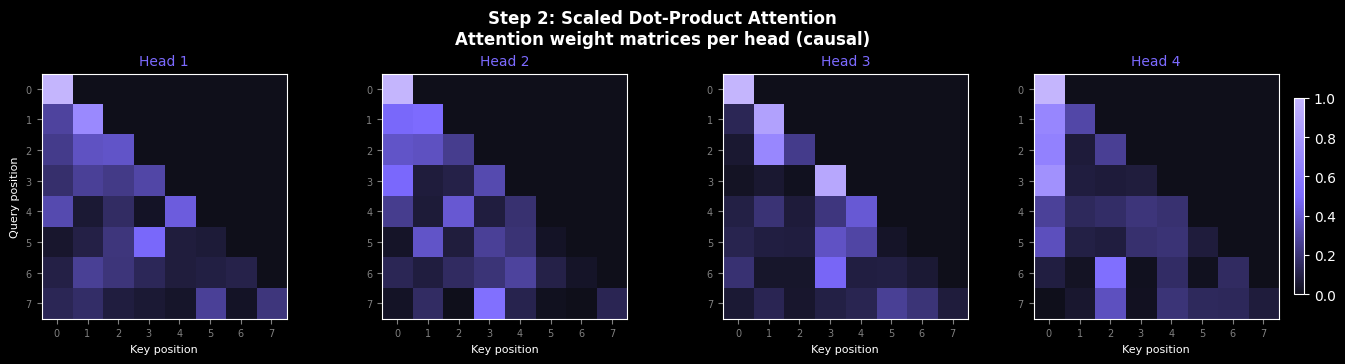

IndexError: The shape of the mask [8, 8] at index 0 does not match the shape of the indexed tensor [1, 8, 8] at index 0

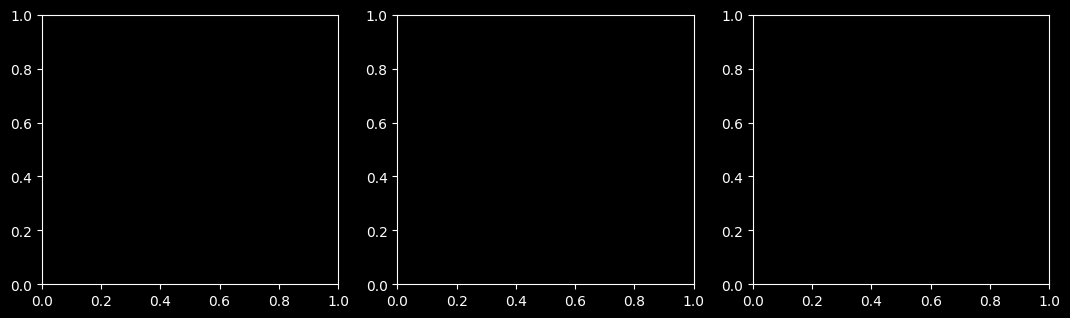

In [14]:
# ── Visualize attention weights for all heads ───────────────────
fig, axes = plt.subplots(1, N_HEADS, figsize=(14, 3.5))
fig.suptitle('Step 2: Scaled Dot-Product Attention\nAttention weight matrices per head (causal)',
             color='white', fontsize=12, fontweight='bold')

cmap = LinearSegmentedColormap.from_list('vp', ['#0f0f1a', '#7c6aff', '#c4b5fd'])

for h in range(N_HEADS):
    w = attn_demo[0, h].detach().numpy()   # (seq, seq)
    im = axes[h].imshow(w, cmap=cmap, vmin=0, vmax=w.max())
    axes[h].set_title(f'Head {h+1}', color=ACCENT, fontsize=10)
    axes[h].set_xlabel('Key position', color='white', fontsize=8)
    if h == 0:
        axes[h].set_ylabel('Query position', color='white', fontsize=8)
    axes[h].tick_params(colors='gray', labelsize=7)

plt.colorbar(im, ax=axes[-1], shrink=0.8)
plt.tight_layout()
plt.show()

# ── Also show Q·Kᵀ raw scores vs post-softmax for head 0
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
head0_scores = torch.matmul(Q_demo[:,0], K_demo[:,0].transpose(-2,-1)) / math.sqrt(D_HEAD)
masked_scores = head0_scores.clone()
masked_scores[causal_mask.squeeze(0).squeeze(0) == 0] = float('-inf')

for ax, data, title in zip(axes,
    [head0_scores[0].detach().numpy(),
     masked_scores[0].detach().numpy(),
     attn_demo[0,0].detach().numpy()],
    ['Raw QKᵀ/√d_k scores', 'After causal mask', 'After softmax (weights)']):
    sns.heatmap(data, ax=ax, cmap='coolwarm', center=0, annot=False,
                linewidths=0.3, cbar=True, square=True)
    ax.set_title(title, color=ACCENT, fontsize=10)
    ax.tick_params(colors='gray', labelsize=7)

plt.suptitle('Attention Score Pipeline (Head 1)', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Multi-Head Attention (MHA)

Linear projections split the residual stream into `N_HEADS` subspaces.  
Each head attends independently, then outputs are concatenated and projected back.

$$\text{MHA}(x) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \, W_O$$
$$\text{head}_i = \text{Attention}(x W_{Q_i},\, x W_{K_i},\, x W_{V_i})$$

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads

        # Q, K, V projections (combined into one matrix each for efficiency)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)  # output projection
        self.dropout = nn.Dropout(dropout)

        self.last_attn_weights = None  # store for visualization

    def forward(self, x, mask=None):
        B, T, D = x.shape
        H, Dh = self.n_heads, self.d_head

        # Project and reshape to (B, H, T, Dh)
        Q = self.W_Q(x).view(B, T, H, Dh).transpose(1, 2)
        K = self.W_K(x).view(B, T, H, Dh).transpose(1, 2)
        V = self.W_V(x).view(B, T, H, Dh).transpose(1, 2)

        # Attend
        attn_out, attn_weights = scaled_dot_product_attention(Q, K, V, mask)
        self.last_attn_weights = attn_weights.detach()  # save for viz

        # Concatenate heads: (B, T, D)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, D)

        # Output projection
        return self.W_O(attn_out)


mha = MultiHeadAttention(D_MODEL, N_HEADS, DROPOUT)
causal_mask_mha = torch.tril(torch.ones(SEQ_LEN, SEQ_LEN)).view(1, 1, SEQ_LEN, SEQ_LEN)

mha_out = mha(x, causal_mask_mha)
print('MHA input shape: ', x.shape)
print('MHA output shape:', mha_out.shape)
print('Parameters in MHA:', sum(p.numel() for p in mha.parameters()))

MHA input shape:  torch.Size([1, 8, 32])
MHA output shape: torch.Size([1, 8, 32])
Parameters in MHA: 4096


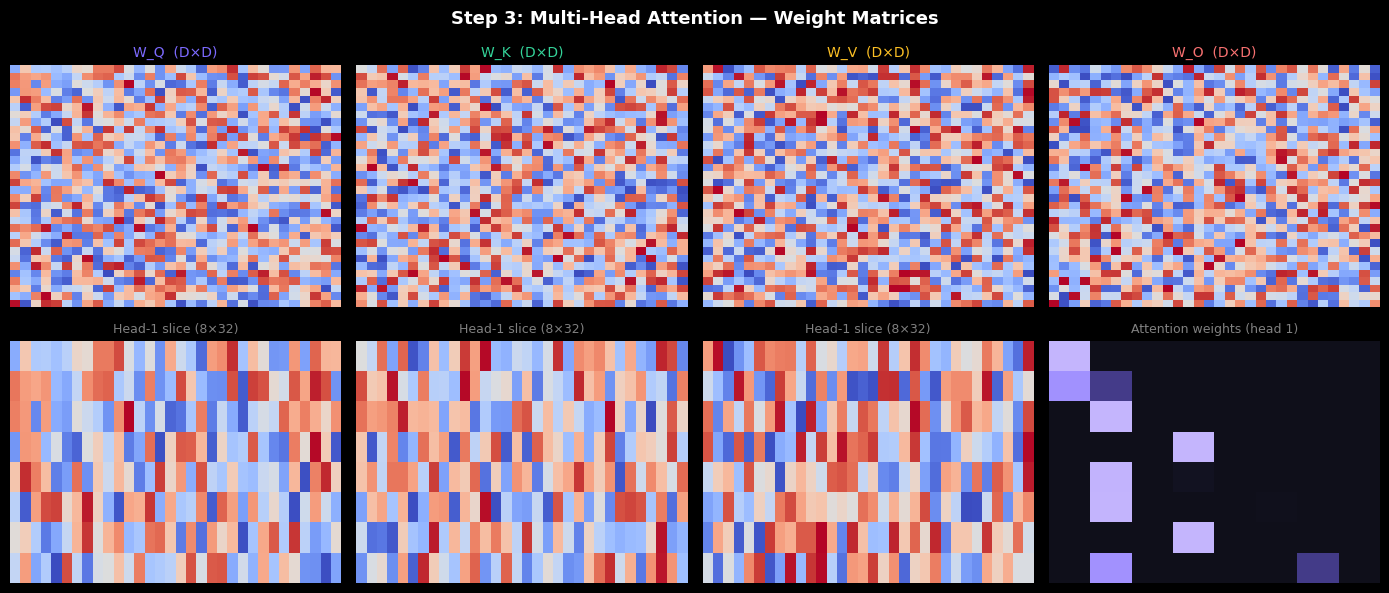

In [16]:
# ── MHA weight matrix visualization ──────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Step 3: Multi-Head Attention — Weight Matrices', color='white', fontsize=13, fontweight='bold')

weight_info = [
    (mha.W_Q.weight.detach().numpy(), 'W_Q  (D×D)', ACCENT),
    (mha.W_K.weight.detach().numpy(), 'W_K  (D×D)', ACCENT2),
    (mha.W_V.weight.detach().numpy(), 'W_V  (D×D)', GOLD),
    (mha.W_O.weight.detach().numpy(), 'W_O  (D×D)', ROSE),
]

for col, (w, label, color) in enumerate(weight_info):
    # Show full matrix
    sns.heatmap(w, ax=axes[0, col], cmap='coolwarm', center=0,
                cbar=False, xticklabels=False, yticklabels=False)
    axes[0, col].set_title(label, color=color, fontsize=10)

    # Show per-head slice of W_Q / W_K / W_V
    if col < 3:
        head0_slice = w[:D_HEAD, :]   # first head's rows
        sns.heatmap(head0_slice, ax=axes[1, col], cmap='coolwarm', center=0,
                    cbar=False, xticklabels=False, yticklabels=False)
        axes[1, col].set_title(f'Head-1 slice ({D_HEAD}×{D_MODEL})', color='gray', fontsize=9)
    else:
        # Show attention weights from MHA
        w_attn = mha.last_attn_weights[0, 0].numpy()  # head 1
        sns.heatmap(w_attn, ax=axes[1, col], cmap=cmap,
                    cbar=False, xticklabels=False, yticklabels=False)
        axes[1, col].set_title('Attention weights (head 1)', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Position-wise Feed-Forward Network (FFN)

Applied independently to each token position. Expands to `4 × d_model` then contracts back.

$$\text{FFN}(x) = \text{GELU}(x W_1 + b_1) W_2 + b_2$$

In [17]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),    # expand: 32 → 128
            nn.GELU(),                    # smooth non-linearity
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),    # contract: 128 → 32
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


ffn = FeedForward(D_MODEL, D_FF, DROPOUT)
ffn_out = ffn(x)
print('FFN input: ', x.shape)
print('FFN output:', ffn_out.shape)
print('Params: W1 =', ffn.net[0].weight.shape, '  W2 =', ffn.net[3].weight.shape)

FFN input:  torch.Size([1, 8, 32])
FFN output: torch.Size([1, 8, 32])
Params: W1 = torch.Size([128, 32])   W2 = torch.Size([32, 128])


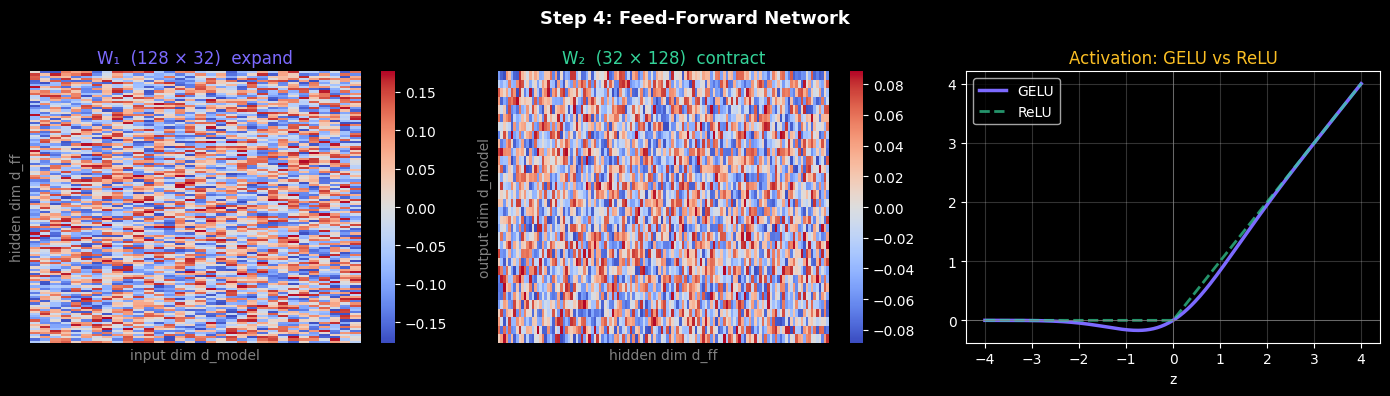

In [18]:
# ── Visualize FFN weights and GELU activation ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Step 4: Feed-Forward Network', color='white', fontsize=13, fontweight='bold')

# W1: (D_FF, D_MODEL) = (128, 32)
sns.heatmap(ffn.net[0].weight.detach().numpy(), ax=axes[0],
            cmap='coolwarm', center=0, cbar=True, xticklabels=False, yticklabels=False)
axes[0].set_title(f'W₁  ({D_FF} × {D_MODEL})  expand', color=ACCENT)
axes[0].set_xlabel('input dim d_model', color='gray')
axes[0].set_ylabel('hidden dim d_ff', color='gray')

# W2: (D_MODEL, D_FF) = (32, 128)
sns.heatmap(ffn.net[3].weight.detach().numpy(), ax=axes[1],
            cmap='coolwarm', center=0, cbar=True, xticklabels=False, yticklabels=False)
axes[1].set_title(f'W₂  ({D_MODEL} × {D_FF})  contract', color=ACCENT2)
axes[1].set_xlabel('hidden dim d_ff', color='gray')
axes[1].set_ylabel('output dim d_model', color='gray')

# GELU activation curve
z = np.linspace(-4, 4, 300)
gelu_vals = z * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))
relu_vals = np.maximum(0, z)
axes[2].plot(z, gelu_vals, color=ACCENT,  linewidth=2.5, label='GELU')
axes[2].plot(z, relu_vals, color=ACCENT2, linewidth=2,   label='ReLU', linestyle='--', alpha=0.7)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].set_title('Activation: GELU vs ReLU', color=GOLD)
axes[2].set_xlabel('z', color='white')
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 6. Residual Connection + Layer Norm

Each sub-layer is wrapped with a **pre-norm** residual connection (used in GPT-2/LLaMA):

$$x_{out} = x + \text{Sublayer}(\text{LayerNorm}(x))$$

LayerNorm normalises across the feature dimension for each token independently.

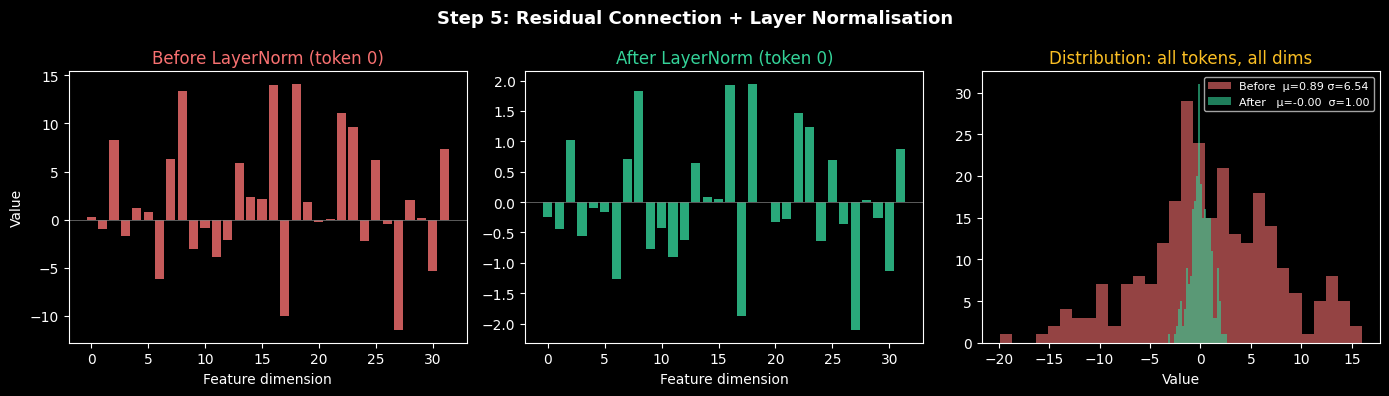

In [19]:
# ── Visualize residual stream before/after LayerNorm ──────────────
ln = nn.LayerNorm(D_MODEL)

# Use a deliberately skewed tensor to show normalization effect
x_skewed = x + torch.randn_like(x) * 3   # add noise for illustration
x_normed = ln(x_skewed)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Step 5: Residual Connection + Layer Normalisation', color='white', fontsize=13, fontweight='bold')

token_idx = 0
axes[0].bar(range(D_MODEL), x_skewed[0, token_idx].detach().numpy(), color=ROSE, alpha=0.8)
axes[0].set_title('Before LayerNorm (token 0)', color=ROSE)
axes[0].set_xlabel('Feature dimension', color='white')
axes[0].set_ylabel('Value', color='white')
axes[0].axhline(0, color='gray', linewidth=0.5)

axes[1].bar(range(D_MODEL), x_normed[0, token_idx].detach().numpy(), color=ACCENT2, alpha=0.8)
axes[1].set_title('After LayerNorm (token 0)', color=ACCENT2)
axes[1].set_xlabel('Feature dimension', color='white')
axes[1].axhline(0, color='gray', linewidth=0.5)

# Show distribution before and after across all tokens
before_flat = x_skewed[0].detach().numpy().flatten()
after_flat  = x_normed[0].detach().numpy().flatten()
axes[2].hist(before_flat, bins=30, alpha=0.6, color=ROSE,   label=f'Before  μ={before_flat.mean():.2f} σ={before_flat.std():.2f}')
axes[2].hist(after_flat,  bins=30, alpha=0.6, color=ACCENT2,label=f'After   μ={after_flat.mean():.2f}  σ={after_flat.std():.2f}')
axes[2].set_title('Distribution: all tokens, all dims', color=GOLD)
axes[2].set_xlabel('Value', color='white')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. The Full Transformer Block

One block = LayerNorm → MHA → residual + LayerNorm → FFN → residual

In [20]:
class TransformerBlock(nn.Module):
    """Single GPT-style transformer block (pre-norm)."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: self-attention with residual
        x = x + self.attn(self.ln1(x), mask)
        # Sub-layer 2: FFN with residual
        x = x + self.ffn(self.ln2(x))
        return x


block = TransformerBlock(D_MODEL, N_HEADS, D_FF, DROPOUT)
block_out = block(x, causal_mask_mha)
print('Block input: ', x.shape)
print('Block output:', block_out.shape)
total_block_params = sum(p.numel() for p in block.parameters())
print(f'Parameters per block: {total_block_params}')

Block input:  torch.Size([1, 8, 32])
Block output: torch.Size([1, 8, 32])
Parameters per block: 12576


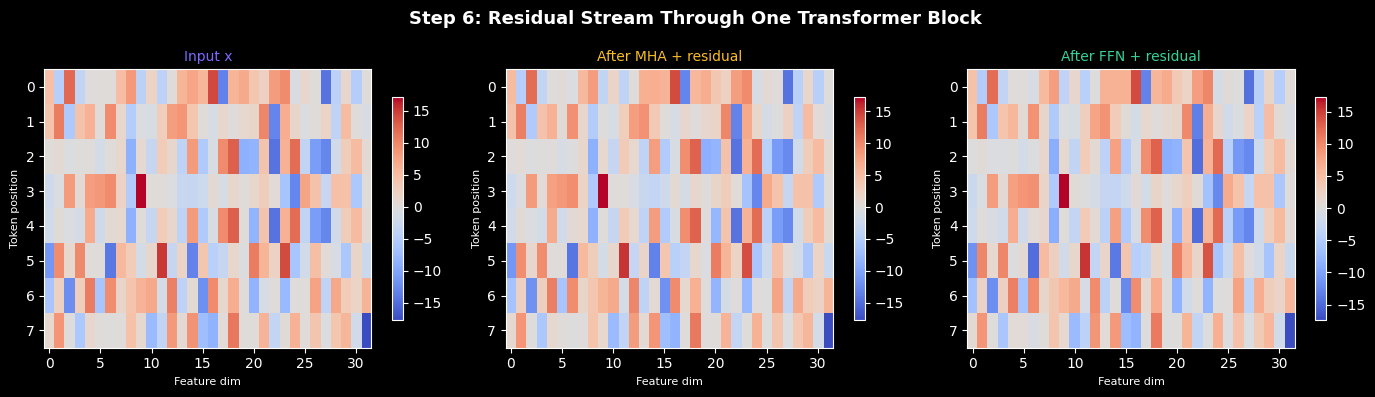

In [21]:
# ── Visualize residual stream evolution through one block ─────────
with torch.no_grad():
    h0  = x[0].detach().numpy()                          # input
    h1  = (x + block.attn(block.ln1(x), causal_mask_mha))[0].detach().numpy()   # after attn
    h2  = block_out[0].detach().numpy()                  # after ffn

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Step 6: Residual Stream Through One Transformer Block', color='white',
             fontsize=13, fontweight='bold')

labels = ['Input x', 'After MHA + residual', 'After FFN + residual']
colors = [ACCENT, GOLD, ACCENT2]
for ax, h, label, col in zip(axes, [h0, h1, h2], labels, colors):
    im = ax.imshow(h, aspect='auto', cmap='coolwarm', interpolation='nearest')
    ax.set_title(label, color=col, fontsize=10)
    ax.set_xlabel('Feature dim', color='white', fontsize=8)
    ax.set_ylabel('Token position', color='white', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

---
## 8. Full GPT-style Language Model

Stack `N_LAYERS` transformer blocks, then project to vocabulary logits.

```
token_ids
  → TokenEmbedding + PositionalEncoding
  → TransformerBlock × N_LAYERS
  → LayerNorm
  → Linear(d_model, vocab_size)   ← language model head
  → logits
```

In [22]:
class GPTModel(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers,
                 max_len=512, dropout=0.1):
        super().__init__()
        self.tok_emb  = TokenEmbedding(vocab_size, d_model)
        self.pos_enc  = SinusoidalPE(d_model, max_len, dropout)
        self.blocks   = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head  = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding weights with lm_head
        self.lm_head.weight = self.tok_emb.embed.weight

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=0.02)

    def forward(self, token_ids):
        B, T = token_ids.shape
        mask = torch.tril(torch.ones(T, T, device=token_ids.device)).view(1, 1, T, T)

        x = self.pos_enc(self.tok_emb(token_ids))   # (B, T, D)

        activations = [x.detach().clone()]           # store for visualization
        for block in self.blocks:
            x = block(x, mask)
            activations.append(x.detach().clone())

        x = self.ln_final(x)
        logits = self.lm_head(x)                     # (B, T, vocab_size)
        return logits, activations


model = GPTModel(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
    d_ff=D_FF, n_layers=N_LAYERS, max_len=MAX_SEQ_LEN, dropout=DROPOUT
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model architecture:\n{model}\n')
print(f'Total parameters: {total_params:,}')

logits, activations = model(token_ids)
print(f'\nInput shape:   {token_ids.shape}')
print(f'Output logits: {logits.shape}  (batch, seq, vocab)')

Model architecture:
GPTModel(
  (tok_emb): TokenEmbedding(
    (embed): Embedding(50, 32)
  )
  (pos_enc): SinusoidalPE(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (W_Q): Linear(in_features=32, out_features=32, bias=False)
        (W_K): Linear(in_features=32, out_features=32, bias=False)
        (W_V): Linear(in_features=32, out_features=32, bias=False)
        (W_O): Linear(in_features=32, out_features=32, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=32, bias=True)
          

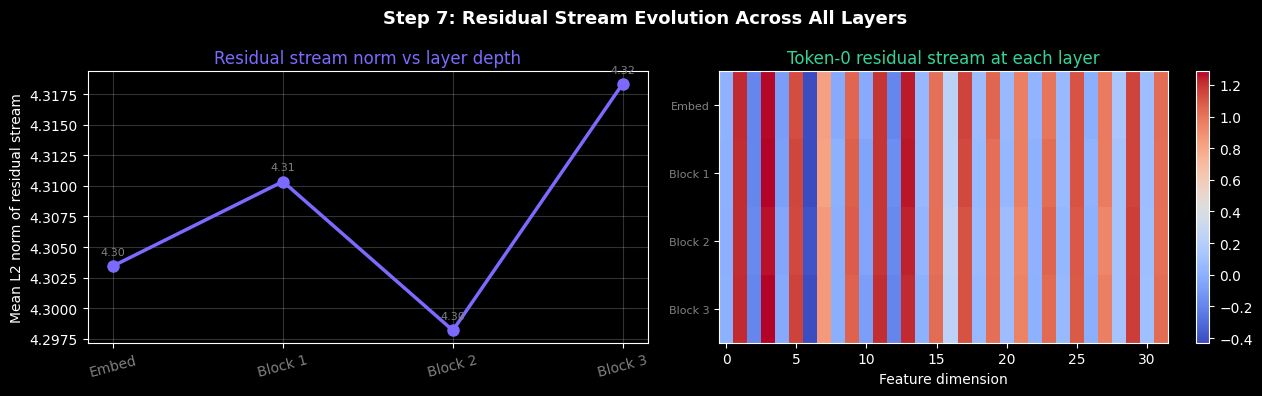

In [23]:
# ── Visualize residual stream norm across all layers ──────────────
layer_norms = [act[0].norm(dim=-1).mean().item() for act in activations]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Step 7: Residual Stream Evolution Across All Layers', color='white',
             fontsize=13, fontweight='bold')

# Norm per layer
layer_labels = ['Embed'] + [f'Block {i+1}' for i in range(N_LAYERS)]
axes[0].plot(range(len(layer_norms)), layer_norms, 'o-', color=ACCENT, linewidth=2.5, markersize=8)
axes[0].set_xticks(range(len(layer_labels)))
axes[0].set_xticklabels(layer_labels, rotation=15, color='gray')
axes[0].set_ylabel('Mean L2 norm of residual stream', color='white')
axes[0].set_title('Residual stream norm vs layer depth', color=ACCENT)
axes[0].grid(alpha=0.2)
for i, v in enumerate(layer_norms):
    axes[0].annotate(f'{v:.2f}', (i, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', color='gray', fontsize=8)

# Heatmap of all activations per layer for one token
all_acts = torch.stack([a[0, 0] for a in activations]).detach().numpy()  # (layers+1, D)
im = axes[1].imshow(all_acts, aspect='auto', cmap='coolwarm', interpolation='nearest')
axes[1].set_yticks(range(len(layer_labels)))
axes[1].set_yticklabels(layer_labels, color='gray', fontsize=8)
axes[1].set_xlabel('Feature dimension', color='white')
axes[1].set_title('Token-0 residual stream at each layer', color=ACCENT2)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

---
## 9. Output Logits & Probability Distribution

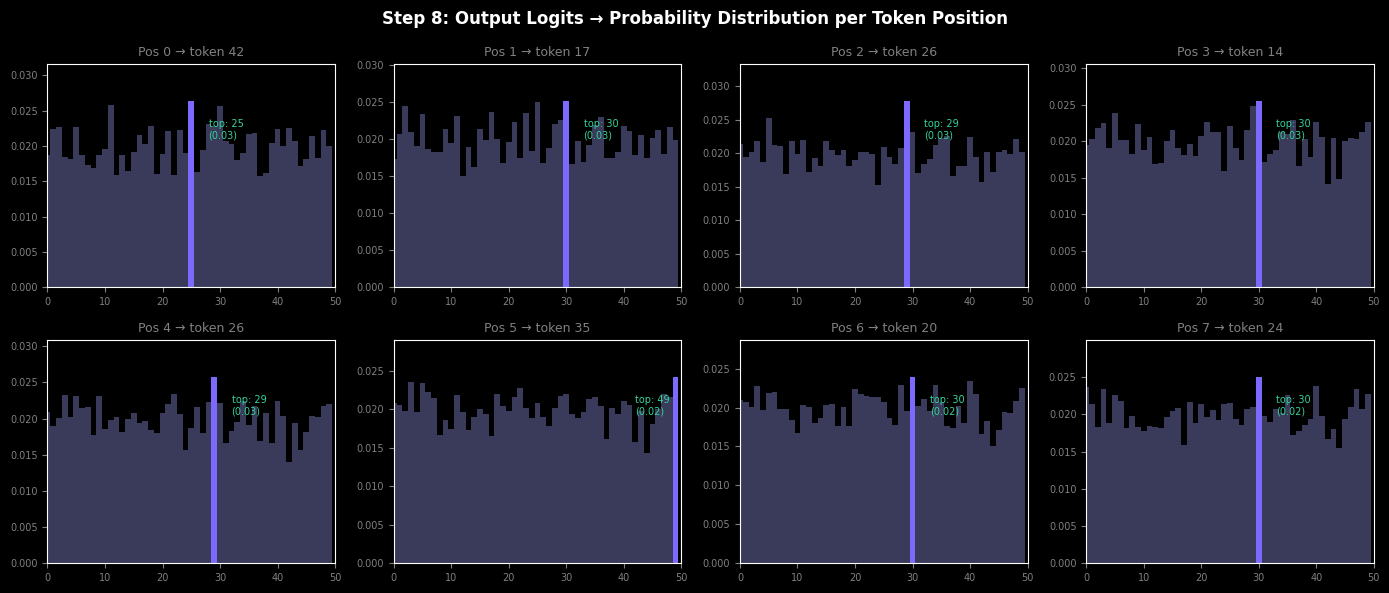

In [24]:
# ── Output logits for every token position ────────────────────────
probs = F.softmax(logits[0], dim=-1).detach().numpy()   # (seq, vocab)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Step 8: Output Logits → Probability Distribution per Token Position',
             color='white', fontsize=12, fontweight='bold')

for pos in range(SEQ_LEN):
    ax = axes[pos // 4][pos % 4]
    p = probs[pos]
    top5_idx = p.argsort()[-5:][::-1]
    bar_colors = [ACCENT if i == p.argmax() else '#3a3a5a' for i in range(VOCAB_SIZE)]
    ax.bar(range(VOCAB_SIZE), p, color=bar_colors, width=1.0)
    ax.set_title(f'Pos {pos} → token {token_ids[0,pos].item()}', color='gray', fontsize=9)
    ax.set_xlim(0, VOCAB_SIZE)
    ax.set_ylim(0, p.max() * 1.2)
    ax.tick_params(colors='gray', labelsize=7)
    top1 = p.argmax()
    ax.annotate(f'top: {top1}\n({p[top1]:.2f})', xy=(top1, p[top1]),
                xytext=(min(top1+3, VOCAB_SIZE-8), p.max()*0.8),
                color=ACCENT2, fontsize=7)

plt.tight_layout()
plt.show()

---
## 10. Attention Pattern Heatmaps (all layers, all heads) — Plotly

In [25]:
# ── Run forward and collect attention weights from all layers ─────
all_attn = []  # list of (n_heads, seq, seq) per layer

with torch.no_grad():
    B, T = token_ids.shape
    mask = torch.tril(torch.ones(T, T)).view(1, 1, T, T)
    h = model.pos_enc(model.tok_emb(token_ids))
    for blk in model.blocks:
        _ = blk(h, mask)
        all_attn.append(blk.attn.last_attn_weights[0].numpy())  # (H, T, T)
        h = blk(h, mask)  # update for next layer (approximate — good enough for viz)

# ── Interactive Plotly heatmaps: layer × head ─────────────────────
fig = make_subplots(
    rows=N_LAYERS, cols=N_HEADS,
    subplot_titles=[f'L{l+1} H{h+1}' for l in range(N_LAYERS) for h in range(N_HEADS)],
    horizontal_spacing=0.04, vertical_spacing=0.08,
)

pos_labels = [str(i) for i in range(SEQ_LEN)]

for l in range(N_LAYERS):
    for h in range(N_HEADS):
        z = all_attn[l][h]   # (T, T)
        fig.add_trace(
            go.Heatmap(
                z=z,
                x=pos_labels, y=pos_labels,
                colorscale='Viridis',
                showscale=(l == 0 and h == N_HEADS - 1),
                zmin=0, zmax=1,
                hovertemplate='Q:%{y} → K:%{x}<br>weight: %{z:.3f}<extra></extra>'
            ),
            row=l+1, col=h+1
        )

fig.update_layout(
    title=dict(text='Attention Patterns — All Layers & Heads', font=dict(size=16, color='white')),
    height=250 * N_LAYERS, width=260 * N_HEADS,
    paper_bgcolor='#0f0f1a', plot_bgcolor='#0f0f1a',
    font=dict(color='white', size=9),
    margin=dict(t=60, b=20, l=20, r=20),
)
fig.update_xaxes(showticklabels=True, tickfont=dict(size=7))
fig.update_yaxes(showticklabels=True, tickfont=dict(size=7))
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

---
## 11. Embedding Space Visualisation (PCA → 2D) — Plotly

In [26]:
# ── Project entire vocab embedding matrix to 2D ───────────────────
with torch.no_grad():
    E = model.tok_emb.embed.weight.numpy()   # (VOCAB_SIZE, D_MODEL)

pca = PCA(n_components=2)
E2d = pca.fit_transform(E)    # (VOCAB_SIZE, 2)

# Colour by token ID (just for visual variety)
fig = go.Figure(go.Scatter(
    x=E2d[:, 0], y=E2d[:, 1],
    mode='markers+text',
    marker=dict(
        size=8,
        color=list(range(VOCAB_SIZE)),
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Token ID')
    ),
    text=[str(i) for i in range(VOCAB_SIZE)],
    textfont=dict(size=8, color='white'),
    textposition='top center',
    hovertemplate='Token %{text}<br>PC1: %{x:.3f}<br>PC2: %{y:.3f}<extra></extra>'
))

# Highlight the tokens in our sample sequence
sample_ids = token_ids[0].tolist()
fig.add_trace(go.Scatter(
    x=E2d[sample_ids, 0], y=E2d[sample_ids, 1],
    mode='markers',
    marker=dict(size=14, color='#f87171', symbol='star',
                line=dict(width=1.5, color='white')),
    name='Sample tokens',
    hovertemplate='Sample token %{customdata}<extra></extra>',
    customdata=sample_ids,
))

fig.update_layout(
    title=dict(text=f'Token Embedding Space — PCA to 2D<br>'
                    f'<sup>Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% | '
                    f'Stars = tokens in our sample sequence</sup>',
               font=dict(size=14, color='white')),
    paper_bgcolor='#0f0f1a', plot_bgcolor='#0f0f1a',
    font=dict(color='white'),
    xaxis_title='Principal Component 1',
    yaxis_title='Principal Component 2',
    height=560, width=750,
    legend=dict(x=0.01, y=0.99)
)
fig.show()

print(f'Explained variance by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

---
## 12. Architecture Summary Diagram — Matplotlib

In [ ]:
def draw_transformer_architecture():
    fig, ax = plt.subplots(figsize=(9, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 22)
    ax.axis('off')
    ax.set_facecolor('#0f0f1a')
    fig.patch.set_facecolor('#0f0f1a')

    def box(x, y, w, h, color, label, sublabel='', text_color='white', fontsize=10):
        rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                        boxstyle='round,pad=0.1',
                                        linewidth=1.5, edgecolor=color,
                                        facecolor=color + '22')
        ax.add_patch(rect)
        ax.text(x, y + (0.12 if sublabel else 0), label,
                ha='center', va='center', color=color,
                fontsize=fontsize, fontweight='bold')
        if sublabel:
            ax.text(x, y - 0.25, sublabel, ha='center', va='center',
                    color='gray', fontsize=7.5)

    def arrow(x, y1, y2, color='#555577'):
        ax.annotate('', xy=(x, y2), xytext=(x, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

    def brace_box(y_lo, y_hi, n_layers):
        rect = mpatches.FancyBboxPatch((0.4, y_lo - 0.3), 9.2, (y_hi - y_lo) + 0.6,
                                        boxstyle='round,pad=0.15', linewidth=1.2,
                                        edgecolor='#3a3a6a', facecolor='#12122a', zorder=0)
        ax.add_patch(rect)
        ax.text(0.75, (y_lo + y_hi) / 2, f'× {n_layers}',
                color='#3a3a6a', fontsize=11, fontweight='bold', rotation=90, va='center')

    cx = 5.0   # center x

    # Input
    box(cx, 1.2, 5, 0.8, '#4b5563', 'Token IDs', f'(batch={BATCH}, seq={SEQ_LEN})')
    arrow(cx, 1.6, 2.3)

    # Embedding
    box(cx, 2.7, 5.5, 0.8, ACCENT, 'Token Embedding', f'Embedding({VOCAB_SIZE}, {D_MODEL})')
    arrow(cx, 3.1, 3.8)

    # Positional encoding
    box(cx, 4.2, 5.5, 0.8, ACCENT2, 'Sinusoidal Positional Encoding', f'PE(pos, d_model={D_MODEL})')
    arrow(cx, 4.6, 5.4)

    # Transformer blocks
    block_top = 5.4
    brace_box(block_top, block_top + 7.2, N_LAYERS)

    box(cx, 6.0, 5, 0.7, '#9ca3af', 'LayerNorm₁', f'ln1 — d_model={D_MODEL}')
    arrow(cx, 6.35, 7.1)

    box(cx, 7.5, 5.5, 0.8, ACCENT, 'Multi-Head Attention', f'{N_HEADS} heads × d_head={D_HEAD}')
    # Residual arrow
    ax.annotate('', xy=(cx + 3.5, 8.3), xytext=(cx + 3.5, 5.8),
                arrowprops=dict(arrowstyle='-', color='#445566', lw=1.2, linestyle='dashed'))
    ax.text(cx + 3.8, 7.05, '+ residual', color='#445566', fontsize=7.5, va='center')
    arrow(cx, 7.9, 8.7)

    box(cx, 9.1, 5, 0.7, '#9ca3af', 'LayerNorm₂', f'ln2 — d_model={D_MODEL}')
    arrow(cx, 9.45, 10.2)

    box(cx, 10.6, 5.5, 0.8, GOLD, 'Feed-Forward Network', f'Linear({D_MODEL}→{D_FF}) → GELU → Linear({D_FF}→{D_MODEL})')
    ax.annotate('', xy=(cx + 3.5, 11.4), xytext=(cx + 3.5, 8.8),
                arrowprops=dict(arrowstyle='-', color='#445566', lw=1.2, linestyle='dashed'))
    ax.text(cx + 3.8, 10.1, '+ residual', color='#445566', fontsize=7.5, va='center')
    arrow(cx, 11.0, 12.6)

    # Final LN
    box(cx, 13.0, 5, 0.7, '#9ca3af', 'Final LayerNorm', f'd_model={D_MODEL}')
    arrow(cx, 13.35, 14.1)

    # LM head
    box(cx, 14.5, 5.5, 0.8, ROSE, 'LM Head  (weight-tied)', f'Linear({D_MODEL}, {VOCAB_SIZE})')
    arrow(cx, 14.9, 15.7)

    # Logits
    box(cx, 16.1, 5, 0.8, '#34d399', 'Logits → Softmax → Token probs',
        f'shape: (batch={BATCH}, seq={SEQ_LEN}, vocab={VOCAB_SIZE})')

    ax.set_title(f'GPT-style Transformer Architecture\n'
                 f'{N_LAYERS} blocks · {N_HEADS} heads · d_model={D_MODEL} · {total_params:,} params',
                 color='white', fontsize=12, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

draw_transformer_architecture()

---
## 13. Parameter Count by Component — Plotly Sunburst

In [ ]:
# ── Break down parameter counts ───────────────────────────────────
def count_params(m): return sum(p.numel() for p in m.parameters())

param_data = {
    'Token Embedding':         count_params(model.tok_emb),
    'Positional Encoding':     0,    # no learned params in sinusoidal PE
}

for i, blk in enumerate(model.blocks):
    param_data[f'Block {i+1} — W_Q']   = count_params(blk.attn.W_Q)
    param_data[f'Block {i+1} — W_K']   = count_params(blk.attn.W_K)
    param_data[f'Block {i+1} — W_V']   = count_params(blk.attn.W_V)
    param_data[f'Block {i+1} — W_O']   = count_params(blk.attn.W_O)
    param_data[f'Block {i+1} — FFN']   = count_params(blk.ffn)
    param_data[f'Block {i+1} — LNorm'] = count_params(blk.ln1) + count_params(blk.ln2)

param_data['Final LayerNorm'] = count_params(model.ln_final)
# LM head is weight-tied — don't double count

labels  = list(param_data.keys())
values  = list(param_data.values())
parents = ['']*2 + \
          [f'Block {(i//6)+1}' for i in range(N_LAYERS*6)] + \
          ['']

# Simple bar chart instead
fig = go.Figure(go.Bar(
    x=labels, y=values,
    marker_color=[ACCENT if 'W_Q' in l or 'W_K' in l or 'W_V' in l or 'W_O' in l
                  else GOLD if 'FFN' in l
                  else ACCENT2 if 'Embed' in l
                  else '#9ca3af'
                  for l in labels],
    text=[f'{v:,}' for v in values],
    textposition='auto',
    hovertemplate='%{x}<br>Parameters: %{y:,}<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'Parameter Count by Component  (total: {total_params:,})',
               font=dict(size=14, color='white')),
    paper_bgcolor='#0f0f1a', plot_bgcolor='#0f0f1a',
    font=dict(color='white'),
    xaxis=dict(tickangle=-40),
    yaxis_title='# Parameters',
    height=450,
)
fig.show()

---
## 14. Gradient Flow Through All Layers

Run a training step with cross-entropy loss and visualize gradient magnitudes.

In [ ]:
# ── Run one training step and inspect gradients ───────────────────
model.train()

# Predict next token: shift targets by 1
logits_train, _ = model(token_ids)
targets = torch.roll(token_ids, -1, dims=1)  # next token targets
loss = F.cross_entropy(logits_train.view(-1, VOCAB_SIZE), targets.view(-1))
loss.backward()

# Collect gradient norms per named parameter
grad_norms = {}
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norms[name] = param.grad.norm().item()

print(f'Loss: {loss.item():.4f}')
print(f'\nTop-10 largest gradients:')
for k, v in sorted(grad_norms.items(), key=lambda x: -x[1])[:10]:
    print(f'  {v:.5f}  {k}')

In [ ]:
# ── Gradient norm bar chart ───────────────────────────────────────
names = list(grad_norms.keys())
norms = list(grad_norms.values())

# Assign color by component type
def grad_color(n):
    if 'W_Q' in n or 'W_K' in n or 'W_V' in n or 'W_O' in n: return ACCENT
    if 'ffn' in n:  return GOLD
    if 'embed' in n: return ACCENT2
    return '#9ca3af'

fig = go.Figure(go.Bar(
    x=names, y=norms,
    marker_color=[grad_color(n) for n in names],
    hovertemplate='%{x}<br>Gradient norm: %{y:.5f}<extra></extra>',
))
fig.update_layout(
    title=dict(text='Gradient Norm per Parameter (one backward pass)',
               font=dict(size=14, color='white')),
    paper_bgcolor='#0f0f1a', plot_bgcolor='#0f0f1a',
    font=dict(color='white', size=9),
    xaxis=dict(tickangle=-55, tickfont=dict(size=8)),
    yaxis_title='Gradient L2 norm',
    height=420,
)
fig.add_hline(y=np.mean(norms), line_dash='dash', line_color='gray',
              annotation_text=f'mean={np.mean(norms):.4f}', annotation_font_color='gray')
fig.show()

---
## Summary

| Component | Shape | What it does |
|---|---|---|
| Token Embedding | `(V, D)` | Lookup table mapping token IDs to dense vectors |
| Positional Encoding | `(1, T, D)` | Adds position signal via sinusoids |
| W_Q, W_K, W_V | `(D, D)` each | Project residual stream into Q/K/V spaces |
| Attention weights | `(B, H, T, T)` | Softmax-normalised similarity scores |
| W_O | `(D, D)` | Project concatenated heads back to residual stream |
| FFN W₁ | `(D_ff, D)` | Expand dimension (×4) |
| FFN W₂ | `(D, D_ff)` | Contract back (÷4) |
| LayerNorm | `2D` (γ, β) | Normalise across feature dim per token |
| LM Head | `(V, D)` | Project to vocabulary logits (weight-tied with embedding) |

**Architecture**: GPT-style decoder-only transformer  
**Config**: `d_model=32, n_heads=4, d_ff=128, n_layers=3, vocab=50`  
**Total parameters**: see cell 8 above